In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect('scarf_docs')
remote_group = repository.open_zarr('tenx_5K_pbmc_rnaseq/data.zarr')

ds = scarf.DataStore(remote_group.store, zarr_mode='r', nthreads=4)
print(ds)

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_S_score', 'RNA_clusters', 
            'RNA_G2M_score', 'RNA_cell_cycle_phase', 'RNA_UMAP1', 'RNA_nCounts', 'RNA_UMAP2', 
            'RNA_doublet_score', 'RNA_leiden_cluster', 'RNA_nFeatures', 'RNA_percentRibo', 'RNA_paris_cluster', 
            'RNA_percentMito'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'feature_type', 'dropOuts', 
            'nCells', 'genome', 'I__hvgs'


Reduction available: True
Graph available: True


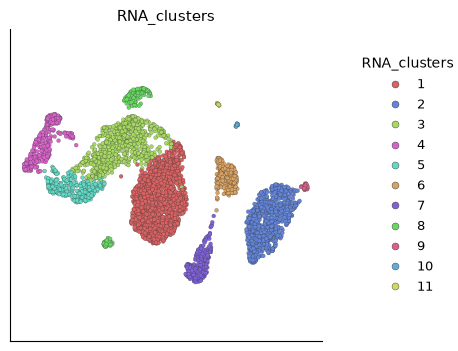

In [2]:
state = ds.get_assay_state('RNA')
print('Reduction available:', state.reduction is not None)
print('Graph available:', state.connectivity_map is not None)

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_clusters',
)

In [3]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import zarr

source_uri = (
    "hf://buckets/Nygen/cytebase/scarf_docs/"
    "tenx_5K_pbmc_rnaseq/data.zarr"
)
mount_directory = TemporaryDirectory()
target_path = Path(mount_directory.name) / 'analysis.zarr'

In [4]:
mounted = scarf.mount_datastore(
    source_uri,
    at=str(target_path),
    storage_options={"token": False},
    nthreads=4,
)

matrix_source = zarr.open_group(str(target_path), mode='r').attrs['matrixSource']
print('Target path:', target_path)
print('Target exists:', target_path.exists())
print('Source URI:', matrix_source['location'])
print('Mounted assays:', sorted(matrix_source['assays']))

Target path: /tmp/tmpah827_m7/analysis.zarr
Target exists: True
Source URI: hf://buckets/Nygen/cytebase/scarf_docs/tenx_5K_pbmc_rnaseq/data.zarr
Mounted assays: ['RNA']


In [5]:
target_root = zarr.open_group(str(target_path), mode='r')

print('Counts stored in target:', 'counts' in target_root['RNA'])
print('Mounted shape:', mounted.RNA.rawData.shape)

Counts stored in target: False
Mounted shape: (5025, 33538)


In [6]:
normalized = mounted.run_normalization(feat_key='hvgs')
pca = mounted.run_pca(normalized, dims=15)

mounted.build_embedding_initialization(pca)
mounted.build_ann_index(pca)
mounted.query_neighbors(k=11)
mounted.build_connectivity_map()
mounted.run_umap(
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="mounted_UMAP",
)
mounted.run_leiden_clustering(
    resolution=0.5,
    label="mounted_clusters",
)

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 100 / 100 complete

ArtifactRef(assay='RNA', kind='cluster_labels', artifact_id='8c07d4795afd...')

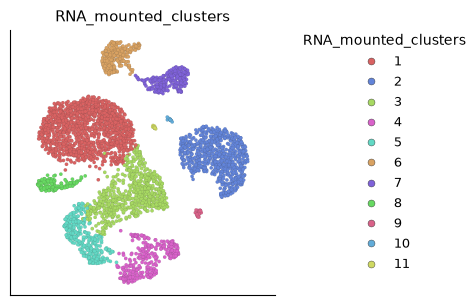

In [7]:
mounted.plots.embedding(
    layout_key="RNA_mounted_UMAP",
    color_by="RNA_mounted_clusters",
)

In [8]:
target_bytes = sum(
    path.stat().st_size
    for path in target_path.rglob("*")
    if path.is_file()
)
logical_count_bytes = int(
    np.prod(mounted.RNA.rawData.shape)
    * mounted.RNA.rawData.dtype.itemsize
)
print("Writable target bytes:", target_bytes)
print("Dense logical count bytes:", logical_count_bytes)

Writable target bytes: 8701363
Dense logical count bytes: 674113800


In [9]:
reopened = scarf.DataStore(
    str(target_path),
    nthreads=4,
    storage_options={"token": False},
)
same_counts = np.array_equal(
    reopened.RNA.rawData[:20, :20].compute(),
    mounted.RNA.rawData[:20, :20].compute(),
)
print('Counts still resolve:', same_counts)
print('Normalization complete:', reopened.inspect_artifact(normalized).complete)

Counts still resolve: True
Normalization complete: True


In [10]:
from pathlib import Path
from tempfile import TemporaryDirectory

scratch_directory = TemporaryDirectory()
scratch_dir = Path(scratch_directory.name) / 'pca_scratch'
normalized = ds.get_assay_state('RNA').normalized
pca = ds.run_pca(
    normalized,
    dims=15,
    local_cache=str(scratch_dir),
    update_state=False,
)
staged_bytes = sum(
    path.stat().st_size for path in scratch_dir.rglob('*') if path.is_file()
)
print('Local cache path:', scratch_dir)
print('Staged normalized bytes:', staged_bytes)
print('Local cache present after PCA:', scratch_dir.exists())
print('Reduction reused:', pca == ds.get_assay_state('RNA').reduction)

Staging normalized data locally: 1 / 1 complete

Local cache path: /tmp/tmp480bjfvb/pca_scratch
Staged normalized bytes: 5826080
Local cache present after PCA: True


Reduction reused: True
